# RIM ablation and forward-run persistence: Figure 6C source-data reanalysis

## tl;dr

This post-publication descriptive reanalysis finds a shorter event-weighted run-duration distribution after RIM ablation in the released Figure 6C table. The source lacks worm IDs for these events, so results are not used for animal-level inference.

## Context & Methods

Source: Ji et al., *eLife* 2021, Figure 6C source-data workbook v3, sheet `Fig 6C`. The question is whether the published run-duration pattern is visible in the released event table and across coarse heading bins. Run events are descriptive units only. No event-level p-values or confidence intervals are computed. The six/twelve direction bins and 30-second tail summary are post-result descriptive choices.

Primary article: https://doi.org/10.7554/eLife.68848. Source-data landing page: https://elifesciences.org/articles/68848v2/figures.

## Data

The workbook contains side-by-side WT and RIM-ablated run direction/duration fields. The analysis runner validates completeness, finite numeric values, positive durations, and records the source SHA-256. It writes a compact summary JSON, direction-bin CSV, and figure under `data/results/M2_RIM_ABLATION_SOURCE_REANALYSIS/`.

In [1]:
from pathlib import Path
import json, runpy

root = Path.cwd().resolve()
while not (root / 'model/M2_RIM_ABLATION_SOURCE_REANALYSIS/analyze_fig6c.py').exists() and root != root.parent:
    root = root.parent
if not (root / 'model/M2_RIM_ABLATION_SOURCE_REANALYSIS/analyze_fig6c.py').exists():
    raise FileNotFoundError('Run this notebook from inside the NeuroMech repository.')
runpy.run_path(str(root / 'model/M2_RIM_ABLATION_SOURCE_REANALYSIS/analyze_fig6c.py'), run_name='__main__')
result_dir = root / 'data/results/M2_RIM_ABLATION_SOURCE_REANALYSIS'
summary = json.loads((result_dir / 'summary.json').read_text())

{
  "wt_events": 1008,
  "rim_ablated_events": 3910,
  "wt_median_duration_s": 17.0,
  "rim_ablated_median_duration_s": 11.5,
  "median_difference_s": -5.5,
  "fraction_ge_30s": {
    "wt": 0.2748015873015873,
    "rim_ablated": 0.11943734015345268
  },
  "all_six_coarse_bin_median_differences_s": [
    -9.0,
    -2.0,
    -1.5,
    -2.5,
    -4.25,
    -9.0
  ],
  "inference": "descriptive only; no worm IDs"
}


## Results

The next cell reports the actual event counts and descriptive differences from the saved machine-readable result. These values do not estimate worm-level uncertainty.

In [2]:
for group in ('wt_event_weighted', 'rim_ablated_event_weighted'):
    x = summary[group]
    print(group, {k: x[k] for k in ('events', 'duration_mean_s', 'duration_median_s', 'duration_q25_s', 'duration_q75_s', 'fraction_duration_ge_30s')})
print('event_weighted_contrast', summary['event_weighted_contrast'])
print('independent_unit:', summary['independent_unit'])

wt_event_weighted {'events': 1008, 'duration_mean_s': 24.490079365079364, 'duration_median_s': 17.0, 'duration_q25_s': 9.5, 'duration_q75_s': 32.0, 'fraction_duration_ge_30s': 0.2748015873015873}
rim_ablated_event_weighted {'events': 3910, 'duration_mean_s': 16.632864450127876, 'duration_median_s': 11.5, 'duration_q25_s': 7.0, 'duration_q75_s': 19.5, 'fraction_duration_ge_30s': 0.11943734015345268}
event_weighted_contrast {'rim_ablated_minus_wt_mean_s': -7.857214914951488, 'rim_ablated_minus_wt_median_s': -5.5, 'rim_ablated_minus_wt_fraction_ge_30s': -0.15536424714813463, 'fraction_ge_30s_relative_reduction': 0.565368812726786}
independent_unit: Not available in this source sheet; event-level summaries are descriptive and are not used for animal-level inference.


Figure saved to /Users/yyl/Desktop/workshop/NMI/nmi_feedback_routing/data/results/M2_RIM_ABLATION_SOURCE_REANALYSIS/figure6c_event_level_descriptive.png


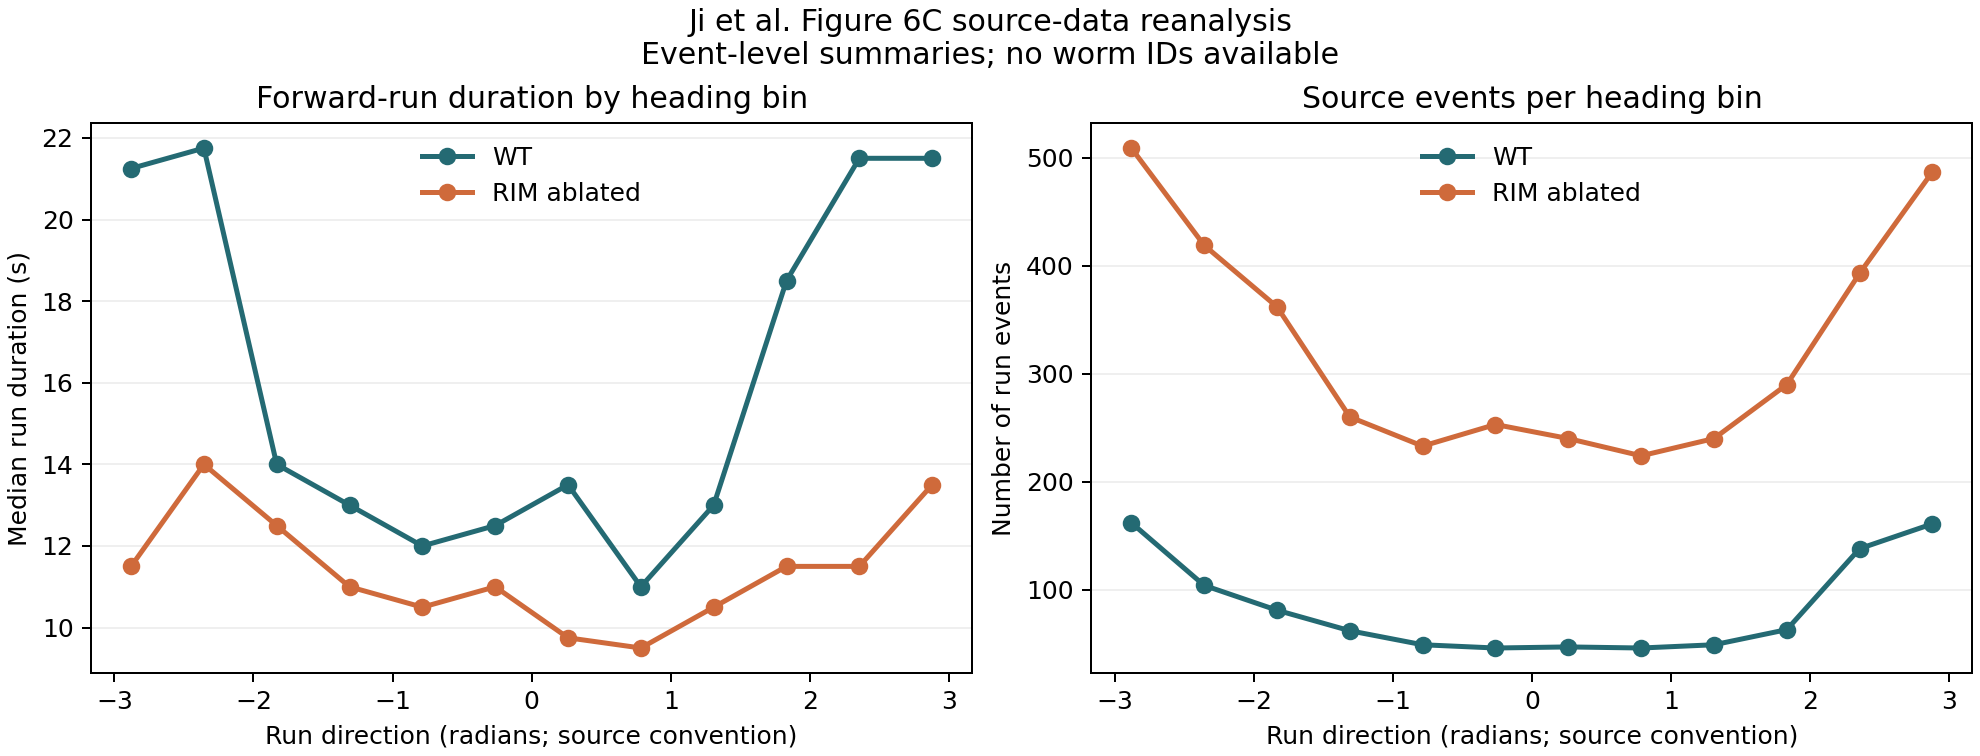

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

bins = pd.read_csv(result_dir / 'direction_bin_descriptives.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
colors = {'WT': '#246a73', 'RIM_ABLATED': '#cf6a3b'}
labels = {'WT': 'WT', 'RIM_ABLATED': 'RIM ablated'}
for group, sub in bins.groupby('group', sort=False):
    center = (sub['direction_left_rad'] + sub['direction_right_rad']) / 2
    axes[0].plot(center, sub['duration_median_s'], marker='o', linewidth=2, color=colors[group], label=labels[group])
    axes[1].plot(center, sub['event_count'], marker='o', linewidth=2, color=colors[group], label=labels[group])
axes[0].set(title='Forward-run duration by heading bin', xlabel='Run direction (radians; source convention)', ylabel='Median run duration (s)')
axes[1].set(title='Source events per heading bin', xlabel='Run direction (radians; source convention)', ylabel='Number of run events')
for ax in axes:
    ax.grid(axis='y', alpha=.2)
    ax.legend(frameon=False)
fig.suptitle('Ji et al. Figure 6C source-data reanalysis\nEvent-level summaries; no worm IDs available')
fig.savefig(result_dir / 'figure6c_event_level_descriptive.png', dpi=180)
print('Figure saved to', result_dir / 'figure6c_event_level_descriptive.png')

## Takeaways

The event table reproduces a lower run-duration distribution after RIM ablation, including lower medians in every one of six coarse direction bins. The event counts are highly unequal (1,008 WT; 3,910 RIM-ablated), and the source does not link these events to worms. The pattern is consistent with the paper's bounded motor-state stabilization claim but cannot be used as a new animal-level estimate or as evidence for a particular synapse or artificial learning algorithm.